# Формирование модели машинного обучения

## Облачные вычислительные системы  
## Лабораторная работа №1:

#### Описание задачи

Рассматривается задача бинарной классификации — по данным о заявителе необходимо предсказать, будет ли одобрен кредит (`Approved`) или отклонён (`Rejected`).

Датасет: [Loan Approval Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset)  
Размер: 4269 записей, 13 столбцов  
Целевая переменная: `loan_status` (`Approved` / `Rejected`)

#### Порядок выполнения работы
1. Загрузка и первичный анализ данных.
2. Очистка данных и кодирование целевой переменной.
3. Разделение выборки на обучающую и тестовую.
4. Построение конвейера обработки данных.
5. Подбор гиперпараметров через GridSearchCV.
6. Оценка качества модели.
7. Сохранение обученного конвейера в `models/pipeline.pkl`.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from pickle import dump, load
from pathlib import Path

#### 1.1 Загрузка данных и просмотр датасета

In [2]:
# Загрузка данных
df = pd.read_csv("../data/loan_approval_dataset.csv")

# Просмотр датасета
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о признаках:")
df.info()
print("\nСтатистика:")
display(df.describe())
print("\nПроверка пропусков:")
print(df.isna().sum())

Размер датасета: (4269, 13)

Первые 5 строк:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Информация о признаках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07



Проверка пропусков:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


## 2. Очистка данных

При загрузке CSV из Kaggle имена столбцов и строковые значения содержат лишние пробелы (например, `' Approved'` вместо `'Approved'`). Это приводит к ошибкам при кодировании целевой переменной.

Также удалим столбец id `loan_id`

In [3]:
# Убираем пробелы в именах столбцов и в строковых значениях
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# Удаляем служебный столбец
df = df.drop(columns=['loan_id'])

# Кодируем целевую переменную: Approved=1, Rejected=0
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

# Определяем список числовых признаков
numeric_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
                'cibil_score', 'residential_assets_value', 'commercial_assets_value',
                'luxury_assets_value', 'bank_asset_value']

# Контрольный вывод
print(f"Размер: {df.shape}")
print(f"Целевая: {df['loan_status'].value_counts().to_dict()}, NaN: {df['loan_status'].isna().sum()}")

# Отрицательные значения — только в числовых признаках
neg_counts = (df[numeric_cols] < 0).sum()
print(f"Отрицательные значения:\n{neg_counts[neg_counts > 0]}")

Размер: (4269, 12)
Целевая: {1: 2656, 0: 1613}, NaN: 0
Отрицательные значения:
residential_assets_value    28
dtype: int64


## 3. Разведочный анализ данных

Посмотрим на распределение целевой переменной и корреляции между признаками.

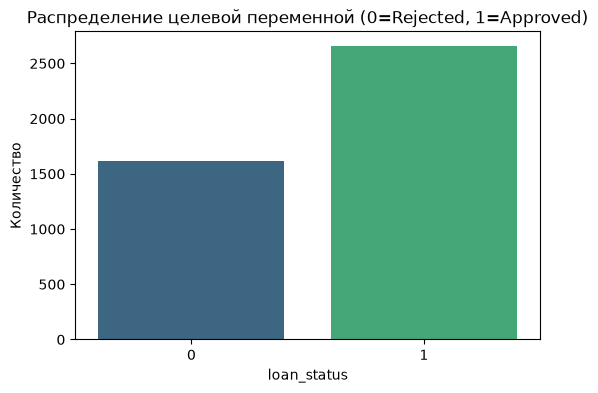

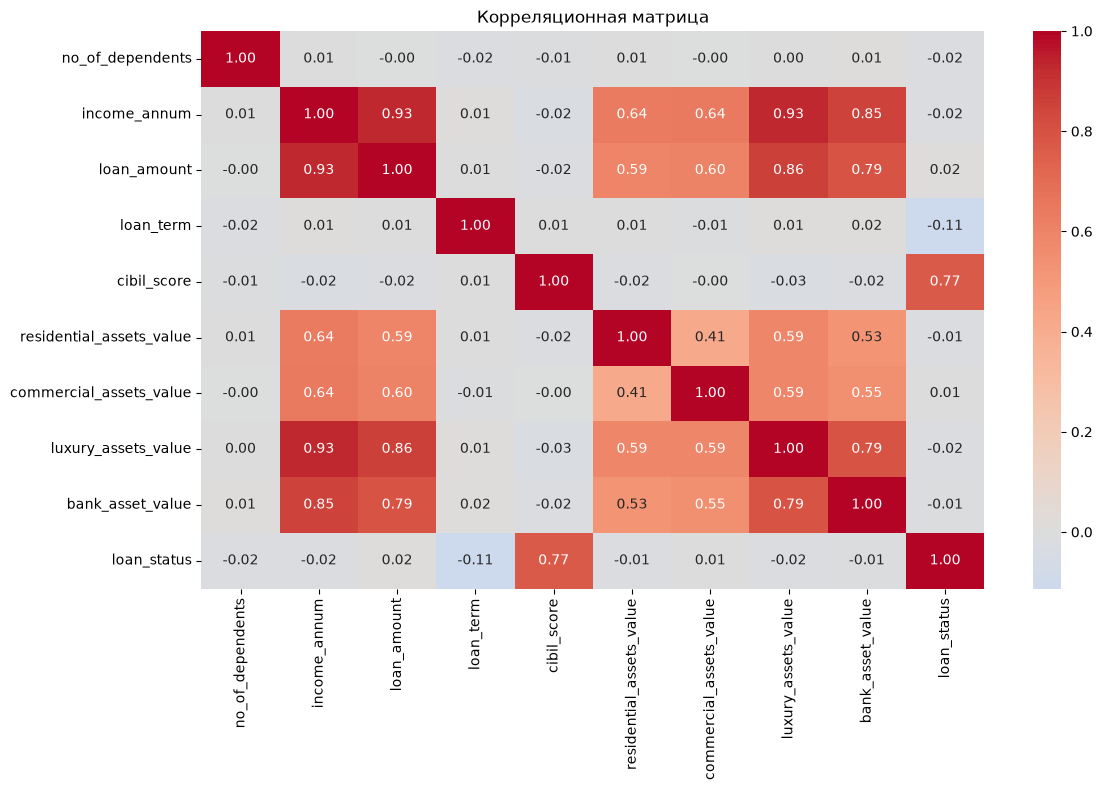

In [4]:
# 3.1. Распределение целевой переменной
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', hue='loan_status', palette='viridis', legend=False)
plt.title('Распределение целевой переменной (0=Rejected, 1=Approved)')
plt.xlabel('loan_status')
plt.ylabel('Количество')
plt.show()

# 3.2. Корреляционная матрица числовых признаков
plt.figure(figsize=(12, 8))
corr = df[numeric_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

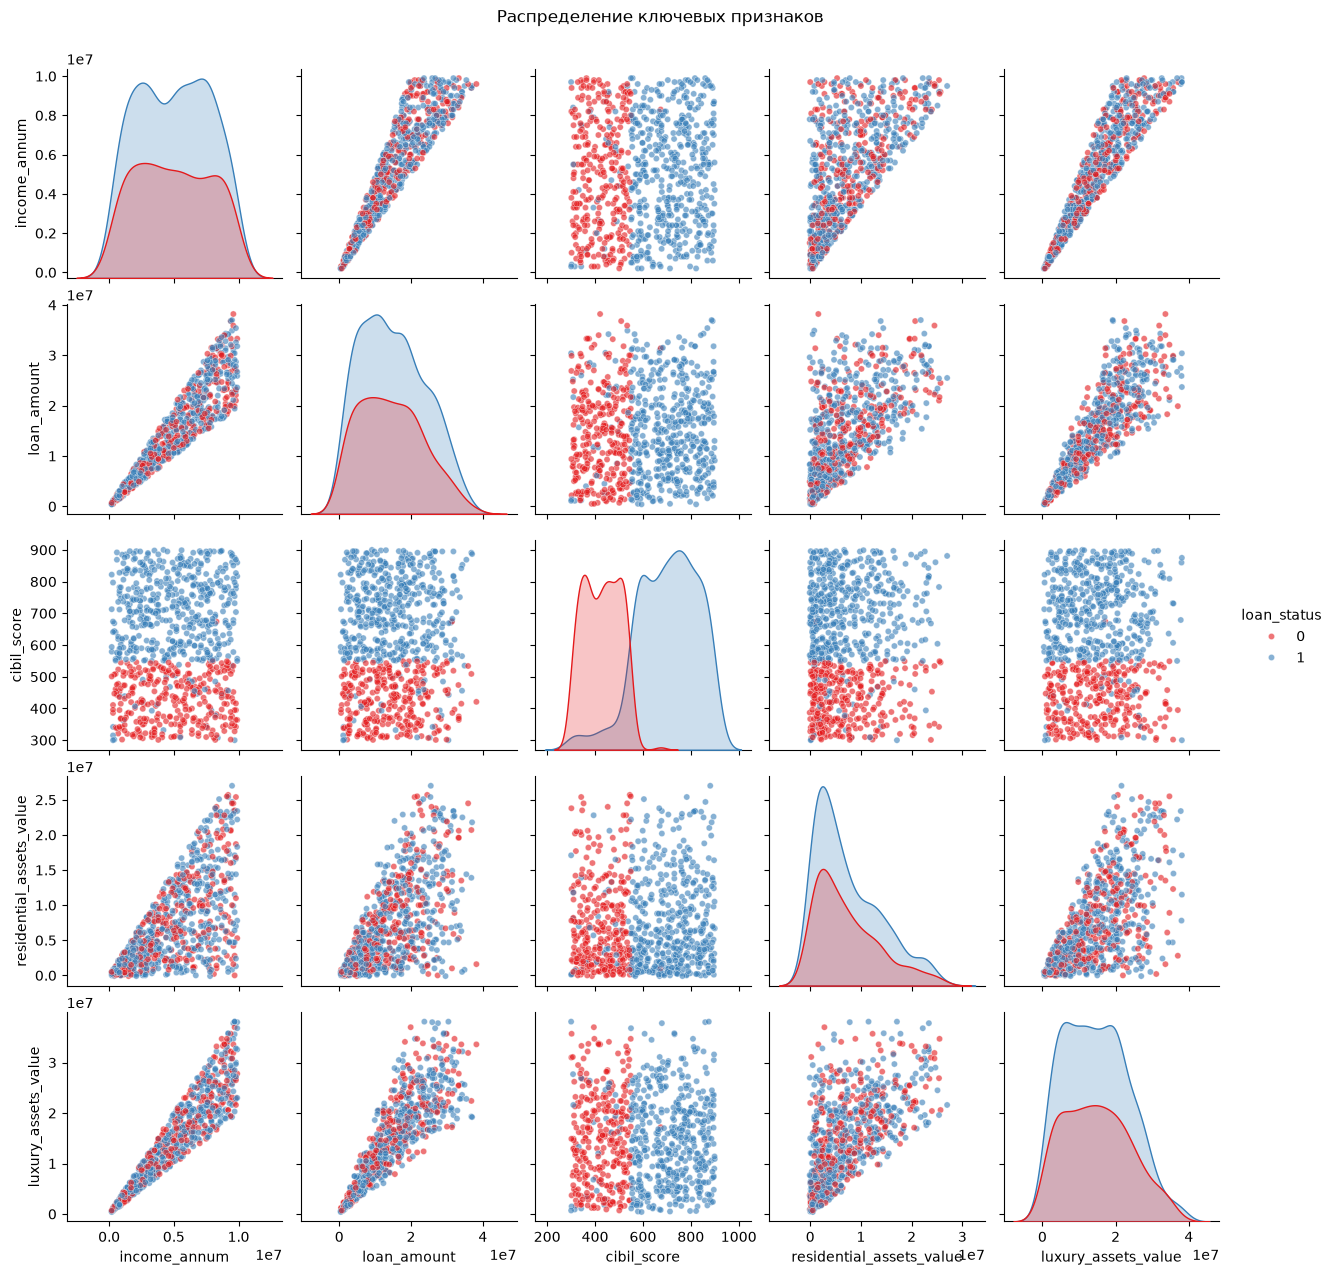

In [5]:
# Ограничимся 5 ключевыми признаками
selected = ['income_annum', 'loan_amount', 'cibil_score',
            'residential_assets_value', 'luxury_assets_value']

# Уменьшенная выборка
df_small = df[selected + ['loan_status']].sample(n=800, random_state=42)

# Pairplot
sns.pairplot(df_small, hue='loan_status', palette='Set1',
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Распределение ключевых признаков', y=1.02)
plt.show()

## 4. Разделение выборки

Разделяем данные на обучающую (80%) и тестовую (20%) выборки.  
Используем стратификацию (`stratify=y`), чтобы пропорции классов сохранились в обеих частях.  
Установим `random_state=42` для воспроизводимости результата.

In [6]:
# Формируем X (признаки) и y (цель)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

print(f"X: {X.shape}, y: {y.shape}")

# Разделение на train/test со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Классы в train: {y_train.value_counts().to_dict()}")
print(f"Классы в test:  {y_test.value_counts().to_dict()}")

X: (4269, 11), y: (4269,)

Train: (3415, 11), Test: (854, 11)
Классы в train: {1: 2125, 0: 1290}
Классы в test:  {1: 531, 0: 323}


## 5. Построение конвейера обработки данных

Сформируем конвейеры для обработки числовых и категориальных признаков:

1) Для обработки числовых признаков заполним пропуски медианой + стандартизация (`StandardScaler`).  
2) Для категориальных признаков пропуски заполним модой + one-hot encoding.  

Модель машинного обучения - `RandomForestClassifier`.

На вход сервиса подаем сырые данные.
Обработка внутри конвеера.

In [7]:
# 5.1. Определяем группы признаков
categorical_features = ['education', 'self_employed']
numeric_features = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
                    'cibil_score', 'residential_assets_value', 'commercial_assets_value',
                    'luxury_assets_value', 'bank_asset_value']

print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")
print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")

# 5.2. Конвейер для числовых признаков
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

print("\nКонвейер для числовых признаков:")
print(numeric_transformer)

Категориальные признаки (2): ['education', 'self_employed']
Числовые признаки (9): ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Конвейер для числовых признаков:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [8]:
# 5.3. Конвейер для категориальных признаков
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

print("Конвейер для категориальных признаков:")
print(categorical_transformer)

Конвейер для категориальных признаков:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])


In [9]:
# 5.4. Объединяем трансформеры через ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

print("ColumnTransformer:")
print(preprocessor)

ColumnTransformer:
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['no_of_dependents', 'income_annum',
                                  'loan_amount', 'loan_term', 'cibil_score',
                                  'residential_assets_value',
                                  'commercial_assets_value',
                                  'luxury_assets_value', 'bank_asset_value']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
       

In [10]:
# 5.5. Финальный конвейер: препроцессинг + классификатор
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
])

print("Финальный Pipeline:")
print(pipeline)

Финальный Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                           

## 6. Подбор гиперпараметров (GridSearchCV)

Перебираем комбинации гиперпараметров Random Forest с 5-кратной кросс-валидацией.

Итого: 2 × 3 × 2 × 2 = 24 комбинации × 5 фолдов = 120 обучений модели.

In [11]:
# 6.1. Сетка гиперпараметров
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

print("Сетка гиперпараметров:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

Сетка гиперпараметров:
  classifier__n_estimators: [100, 200]
  classifier__max_depth: [None, 10, 20]
  classifier__min_samples_split: [2, 5]
  classifier__min_samples_leaf: [1, 2]


In [12]:
# 6.2. GridSearchCV
search_cv = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

# 6.3. Обучение
print("Запуск GridSearchCV...")
search_cv.fit(X_train, y_train)

Запуск GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['no_of_dependents',
                                                                          'income_annum',
                                                                          'loan_amount',
                                                                          'loan_term',
                                                                          'cibil_score',
                                                                          'residential_assets_value',
                                                                          'commercial_assets_value',
                                                                          'luxury_assets_value',
                                                                          'bank_...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['education',
                                                                          'self_employed'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [13]:
# 6.4. Лучшие параметры и метрика
print("Best params:")
print(search_cv.best_params_)

print(f"\nЛучшая accuracy на кросс-валидации: {search_cv.best_score_:.4f}")

Best params:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Лучшая accuracy на кросс-валидации: 0.9813


## 7. Оценка качества модели

Оцениваем финальную модель на тестовой выборке.

In [14]:
# 7.1. Accuracy на train и test
train_acc = search_cv.score(X_train, y_train)
test_acc = search_cv.score(X_test, y_test)

print("=" * 60)
print(f"Accuracy на обучающей выборке: {train_acc:.4f}")
print(f"Accuracy на тестовой выборке:  {test_acc:.4f}")
print("=" * 60)

# 7.2. Предсказания на тесте
y_pred = search_cv.predict(X_test)

# 7.3. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Accuracy на обучающей выборке: 1.0000
Accuracy на тестовой выборке:  0.9813

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.98      0.98       323
    Approved       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



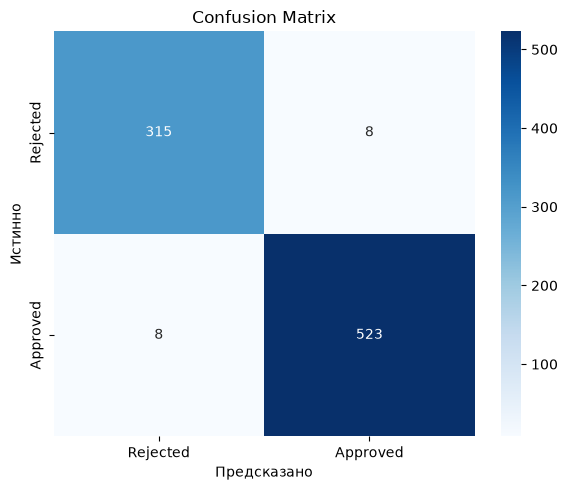

In [15]:
# 7.4. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

# 7.5. Визуализация матрицы ошибок
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.xlabel('Предсказано')
plt.ylabel('Истинно')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. Сохранение обученного конвейера

Сохраняем весь конвейер в файл `models/pipeline.pkl`.  
Этот файл будем загружать веб-сервис для инференса.

In [16]:
# 8.1. Достаём лучшую модель из GridSearchCV
best_model = search_cv.best_estimator_

# 8.2. Создаём папку models
Path("../models").mkdir(parents=True, exist_ok=True)

# 8.3. Сохраняем конвейер через pickle
with open("../models/pipeline.pkl", "wb") as file:
    dump(best_model, file)

print("Модель сохранена в: ../models/pipeline.pkl")

Модель сохранена в: ../models/pipeline.pkl


## 9. Тестирование на сырых данных

Проверим обученную модель на сырых данных

In [17]:
# 9. Проверка: загружаем модель и делаем предсказание на «сырых» данных
with open("../models/pipeline.pkl", "rb") as file:
    loaded_model = load(file)

print(f"Модель загружена, тип: {type(loaded_model).__name__}")

# Тестовый объект
test_instance = {
    'no_of_dependents': 2,
    'education': 'Graduate',
    'self_employed': 'No',
    'income_annum': 9600000,
    'loan_amount': 29900000,
    'loan_term': 12,
    'cibil_score': 778,
    'residential_assets_value': 2400000,
    'commercial_assets_value': 1760000,
    'luxury_assets_value': 22700000,
    'bank_asset_value': 8000000
}

test_df = pd.DataFrame([test_instance])
prediction = loaded_model.predict(test_df)[0]
probabilities = loaded_model.predict_proba(test_df)[0]

print("\nТестовое предсказание на сырых данных:")
print(f"  Вход: {test_instance}")
print(f"  Предсказание: {prediction} ({'Approved' if prediction == 1 else 'Rejected'})")
print(f"  Вероятности: Rejected={probabilities[0]:.4f}, Approved={probabilities[1]:.4f}")

Модель загружена, тип: Pipeline

Тестовое предсказание на сырых данных:
  Вход: {'no_of_dependents': 2, 'education': 'Graduate', 'self_employed': 'No', 'income_annum': 9600000, 'loan_amount': 29900000, 'loan_term': 12, 'cibil_score': 778, 'residential_assets_value': 2400000, 'commercial_assets_value': 1760000, 'luxury_assets_value': 22700000, 'bank_asset_value': 8000000}
  Предсказание: 1 (Approved)
  Вероятности: Rejected=0.0300, Approved=0.9700
